# Customer Data Exploration & Analysis

This notebook performs exploratory data analysis (EDA) on customer data to understand patterns, distributions, and relationships that will inform our churn prediction model.

**Objectives:**
- Understand data structure and quality
- Identify key features influencing customer behavior
- Discover patterns in customer segments
- Prepare insights for model development

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Data Loading & Overview

Load the customer dataset and examine its basic structure.

In [2]:
# Load data
df = pd.read_csv('https://hebbkx1anhila5yf.public.blob.vercel-storage.com/customers-U4gvxvVdWa3Zj0vNi60C1y3tPnenkS.csv', 
                 delimiter='\t')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head()

Dataset Shape: 2240 rows × 29 columns

Memory Usage: 0.86 MB


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# Data types and basic info
print("Column Data Types:")
print(df.dtypes)
print("\n" + "="*50)
df.info()

Column Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 t

## 2. Data Quality Assessment

Check for missing values, duplicates, and data quality issues.

In [4]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

if missing_df['Missing_Count'].sum() == 0:
    print("\n✓ No missing values found!")

Missing Values Summary:
        Missing_Count  Percentage
Income             24    1.071429


In [5]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

if duplicates == 0:
    print("✓ No duplicate records found!")

Duplicate Rows: 0
✓ No duplicate records found!


## 3. Target Variable Analysis

Analyze the distribution of our target variable: **Response** (churn indicator).

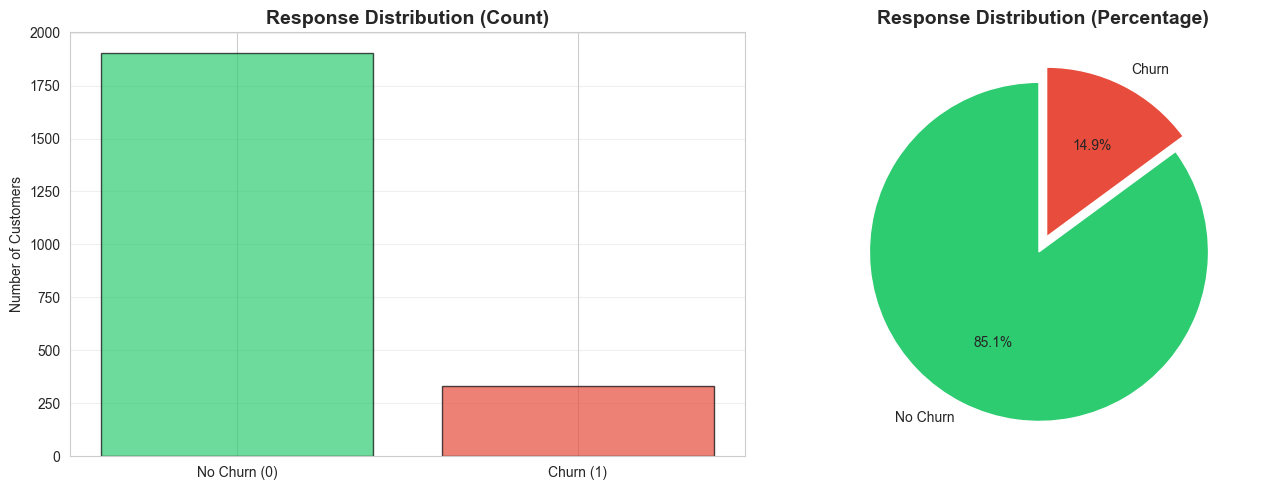


Class Distribution:
No Churn (0): 1906 (85.09%)
Churn (1): 334 (14.91%)

Class Imbalance Ratio: 1:5.71


In [6]:
# Response distribution
response_counts = df['Response'].value_counts()
response_pct = df['Response'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].bar(['No Churn (0)', 'Churn (1)'], response_counts.values, 
            color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_title('Response Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
axes[1].pie(response_pct.values, labels=['No Churn', 'Churn'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Response Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nClass Distribution:")
print(f"No Churn (0): {response_counts[0]} ({response_pct[0]:.2f}%)")
print(f"Churn (1): {response_counts[1]} ({response_pct[1]:.2f}%)")
print(f"\nClass Imbalance Ratio: 1:{response_counts[0]/response_counts[1]:.2f}")

## 4. Numerical Features Analysis

Examine distributions and statistics of key numerical features.

In [7]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('ID')  # Remove ID column

# Descriptive statistics
print("Numerical Features Summary Statistics:")
df[numerical_cols].describe().round(2)

Numerical Features Summary Statistics:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,...,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.0,2240.0,2240.00
mean,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,27.06,...,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.0,11.0,0.15
std,11.98,25173.08,0.54,0.54,28.96,336.60,39.77,225.72,54.63,41.28,...,2.43,0.26,0.26,0.26,0.25,0.11,0.10,0.0,0.0,0.36
min,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
25%,1959.00,35303.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,1.00,...,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
50%,1970.00,51381.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,8.00,...,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
75%,1977.00,68522.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,33.00,...,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
max,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,263.00,...,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.0,11.0,1.00


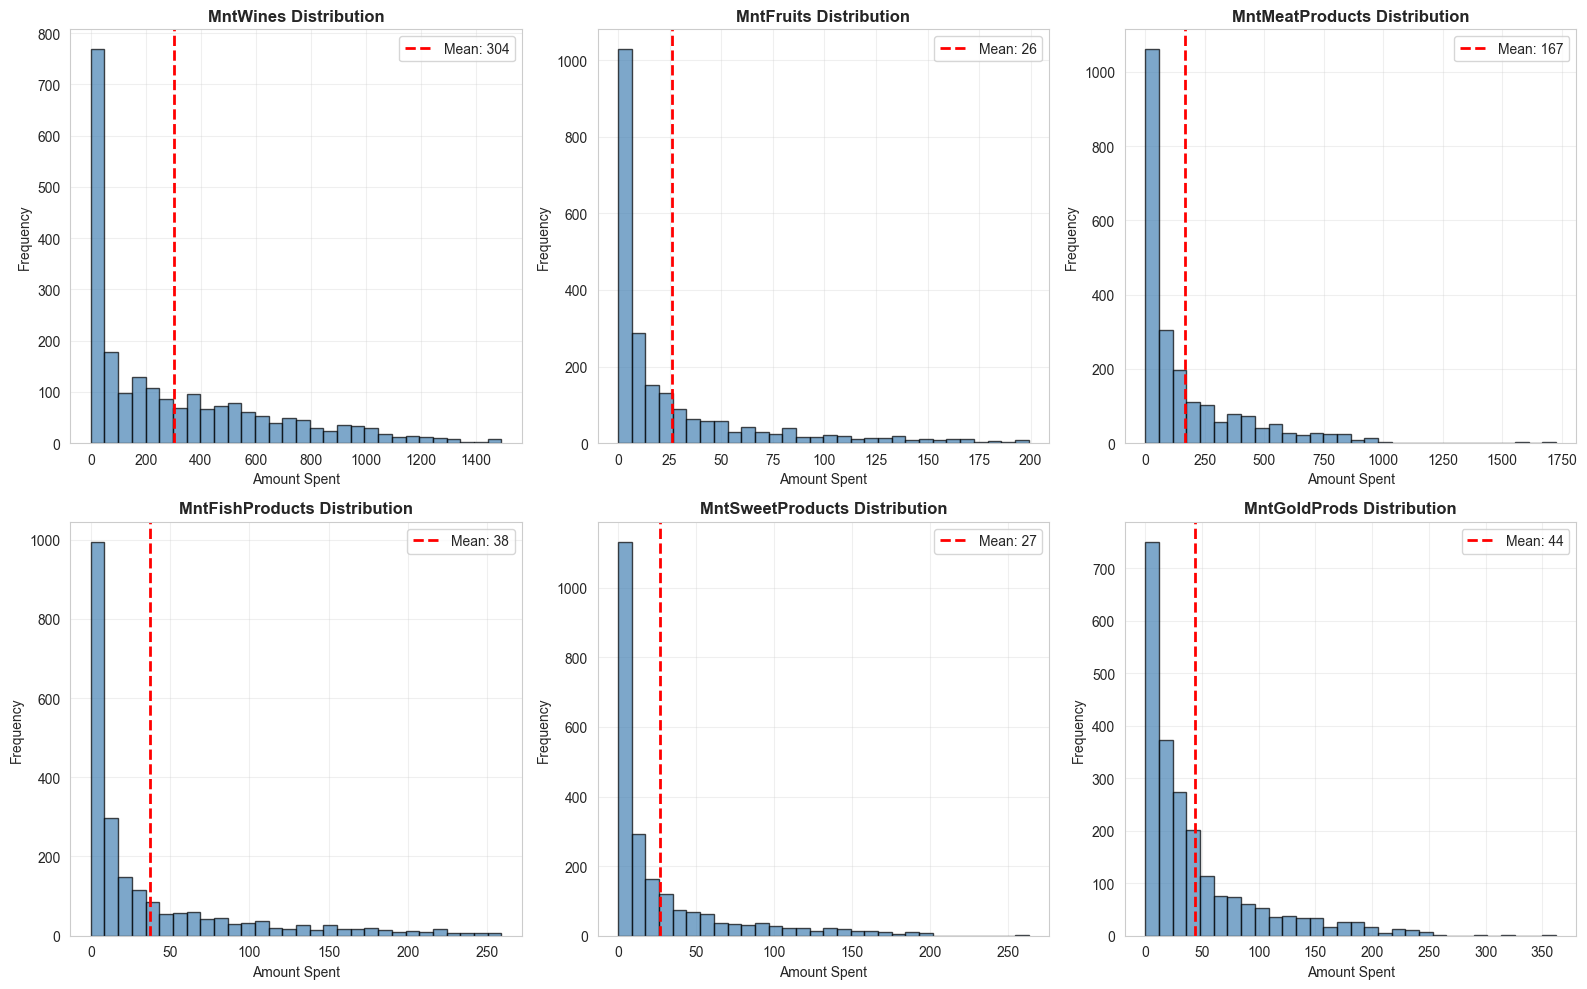

In [8]:
# Distribution of key spending features
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(spending_cols):
    axes[idx].hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_xlabel('Amount Spent')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', 
                      linewidth=2, label=f'Mean: {df[col].mean():.0f}')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

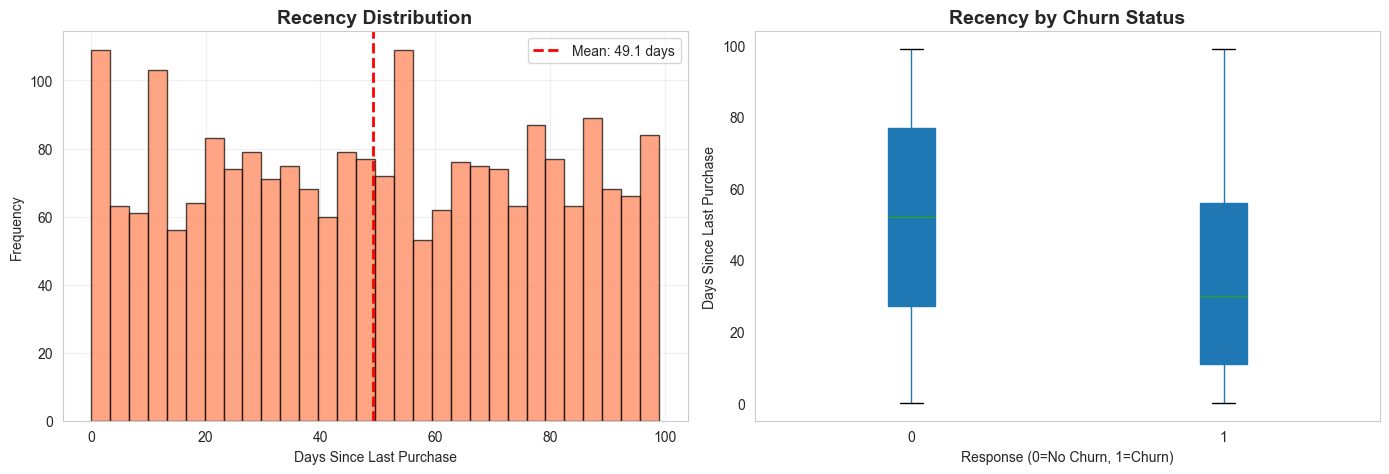


Recency Statistics by Churn Status:
           count   mean    std  min   25%   50%   75%   max
Response                                                   
0         1906.0  51.51  28.52  0.0  27.0  52.0  77.0  99.0
1          334.0  35.38  27.66  0.0  11.0  30.0  56.0  99.0


In [9]:
# Recency analysis (most important feature from SHAP)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recency distribution
axes[0].hist(df['Recency'], bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[0].set_title('Recency Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Recency'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {df["Recency"].mean():.1f} days')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Recency by Response
df.boxplot(column='Recency', by='Response', ax=axes[1], 
           patch_artist=True, grid=False)
axes[1].set_title('Recency by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Response (0=No Churn, 1=Churn)')
axes[1].set_ylabel('Days Since Last Purchase')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

print(f"\nRecency Statistics by Churn Status:")
print(df.groupby('Response')['Recency'].describe().round(2))

## 5. Categorical Features Analysis

Explore categorical variables like Education and Marital Status.

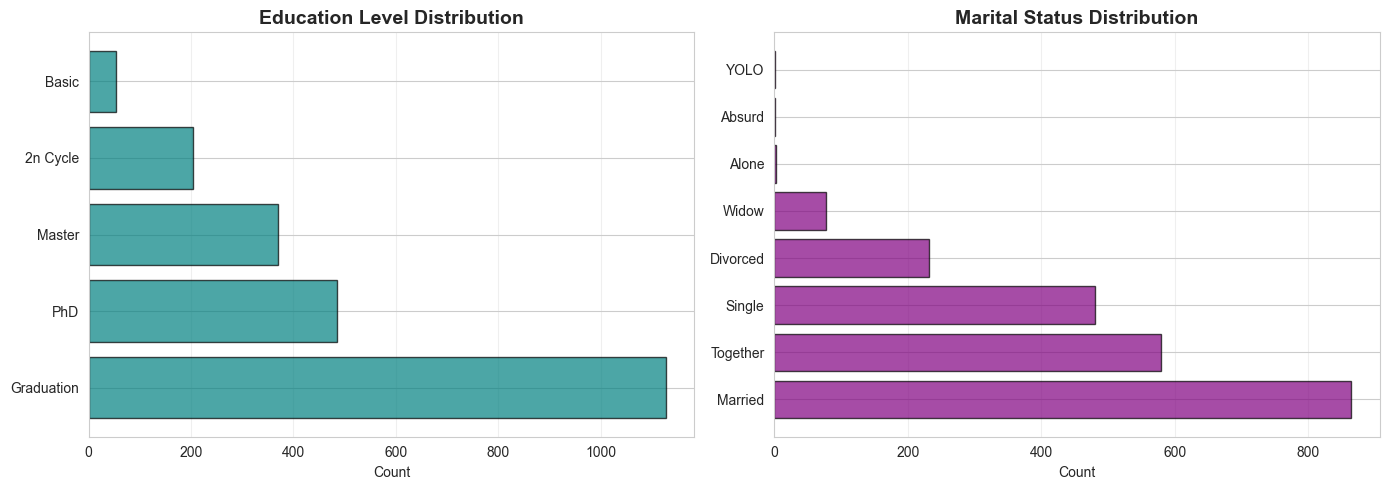

In [10]:
# Education distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

education_counts = df['Education'].value_counts()
axes[0].barh(education_counts.index, education_counts.values, 
             color='teal', alpha=0.7, edgecolor='black')
axes[0].set_title('Education Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].grid(axis='x', alpha=0.3)

# Marital Status distribution
marital_counts = df['Marital_Status'].value_counts()
axes[1].barh(marital_counts.index, marital_counts.values, 
             color='purple', alpha=0.7, edgecolor='black')
axes[1].set_title('Marital Status Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feature Correlations

Analyze relationships between features to identify multicollinearity and feature importance.

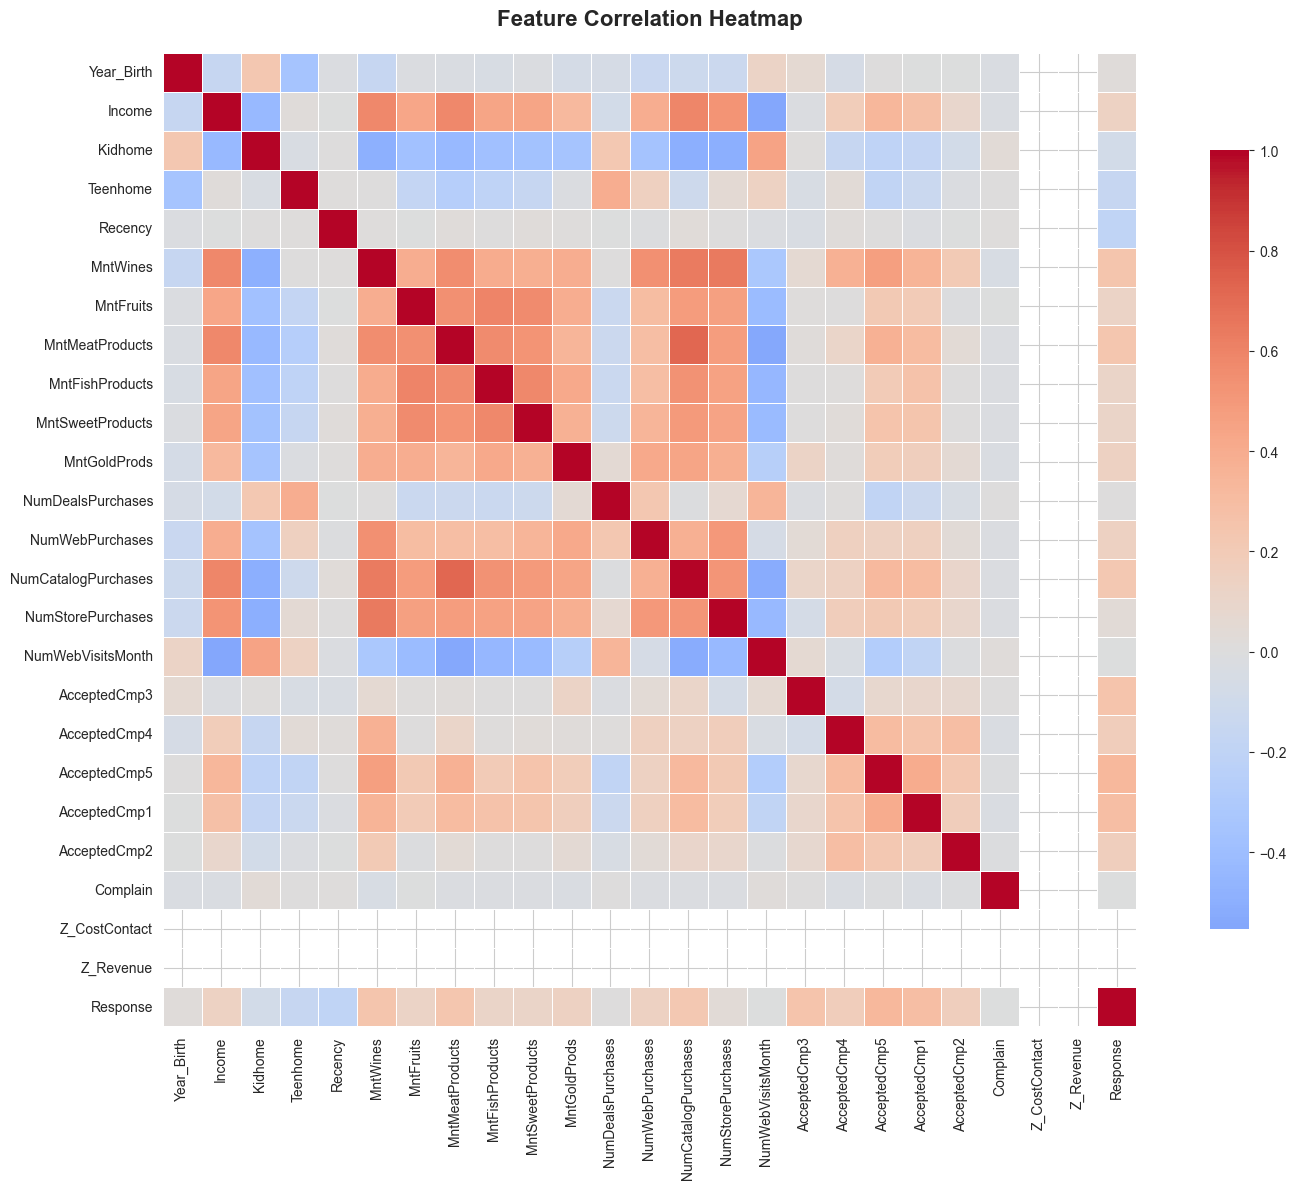


Top 10 Features Correlated with Response (Churn):
Response               1.000
AcceptedCmp5           0.327
AcceptedCmp1           0.294
AcceptedCmp3           0.254
MntWines               0.247
MntMeatProducts        0.236
NumCatalogPurchases    0.221
AcceptedCmp4           0.177
AcceptedCmp2           0.169
NumWebPurchases        0.149
MntGoldProds           0.140
Name: Response, dtype: float64


In [11]:
# Correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with Response
response_corr = correlation_matrix['Response'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Response (Churn):")
print(response_corr.head(11).round(3))  # 11 to exclude Response itself

## 7. Campaign Acceptance Analysis

Analyze customer response to marketing campaigns.

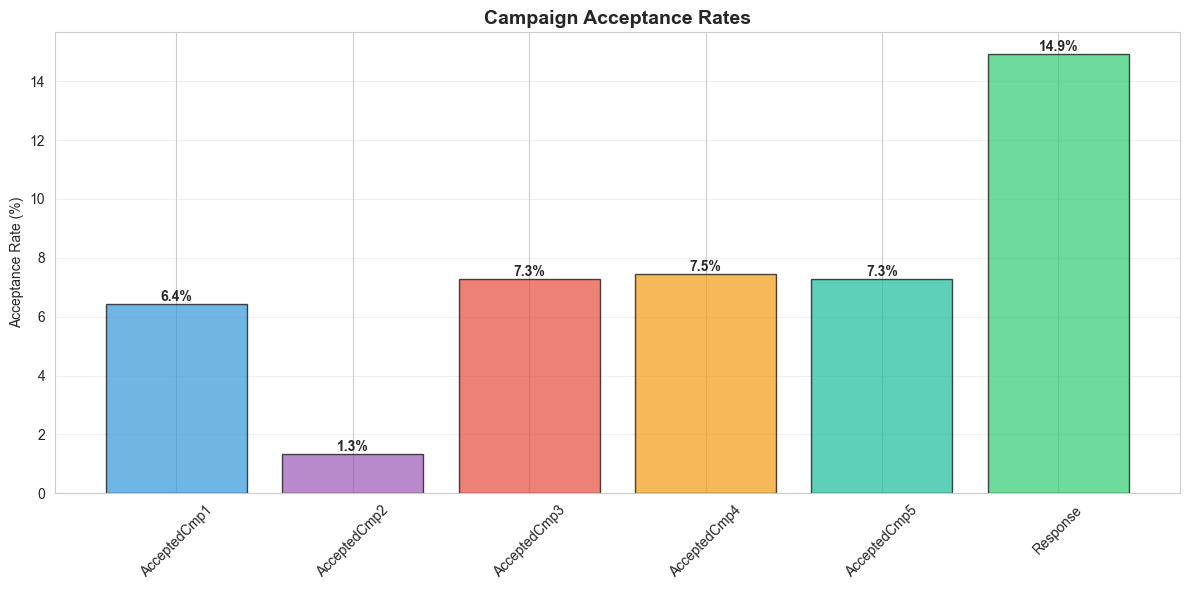


Average Campaign Score: 0.45
Max Campaign Score: 5


In [12]:
# Campaign acceptance rates
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

campaign_acceptance = df[campaign_cols].sum()
campaign_rate = (campaign_acceptance / len(df)) * 100

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(campaign_cols)), campaign_rate.values, 
               color=['#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#2ecc71'],
               alpha=0.7, edgecolor='black')
plt.xticks(range(len(campaign_cols)), campaign_cols, rotation=45)
plt.title('Campaign Acceptance Rates', fontsize=14, fontweight='bold')
plt.ylabel('Acceptance Rate (%)')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Total campaign score
df['CampaignScore'] = df[campaign_cols].sum(axis=1)
print(f"\nAverage Campaign Score: {df['CampaignScore'].mean():.2f}")
print(f"Max Campaign Score: {df['CampaignScore'].max()}")

## 8. Purchase Behavior Analysis

Examine customer purchase patterns across different channels.

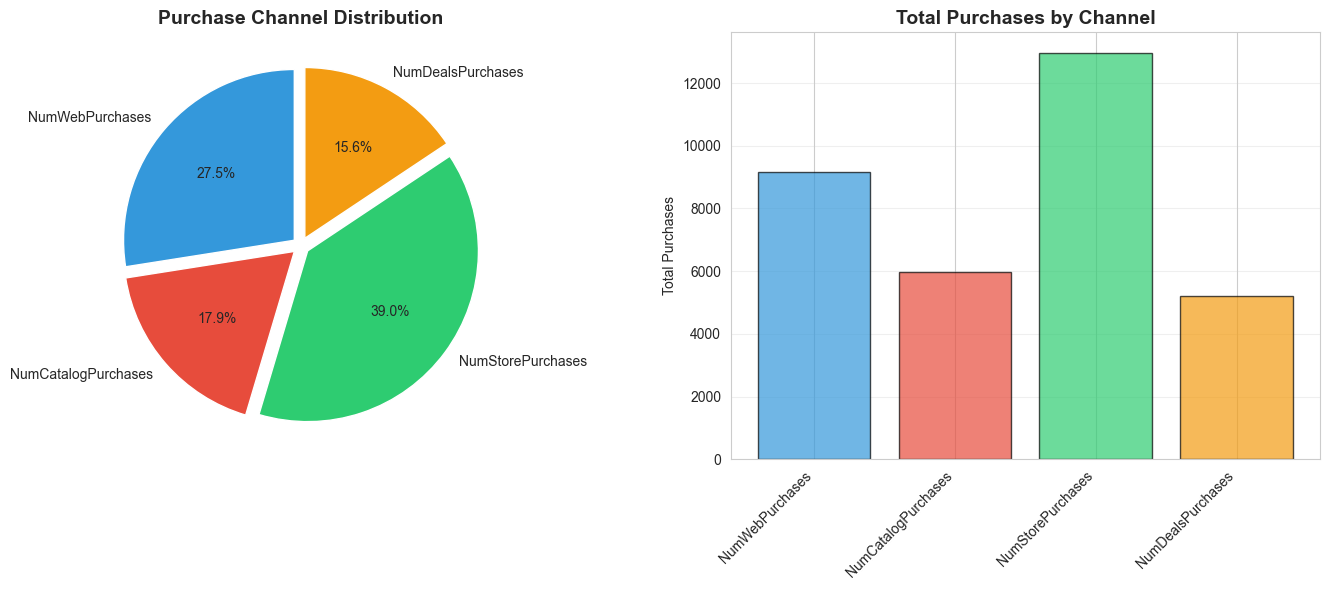


Average Purchases per Customer by Channel:
NumWebPurchases        4.08
NumCatalogPurchases    2.66
NumStorePurchases      5.79
NumDealsPurchases      2.33
dtype: float64


In [13]:
# Purchase channel analysis
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 
                 'NumStorePurchases', 'NumDealsPurchases']

purchase_totals = df[purchase_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(purchase_totals.values, labels=purchase_cols, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
            startangle=90, explode=(0.05, 0.05, 0.05, 0.05))
axes[0].set_title('Purchase Channel Distribution', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(range(len(purchase_cols)), purchase_totals.values,
            color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
            alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(purchase_cols)))
axes[1].set_xticklabels(purchase_cols, rotation=45, ha='right')
axes[1].set_title('Total Purchases by Channel', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Purchases')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAverage Purchases per Customer by Channel:")
print(df[purchase_cols].mean().round(2))

## 9. Key Insights Summary

Summarize the main findings from our exploratory analysis.

In [14]:
print("="*60)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*60)

print("\n1. DATA QUALITY:")
print(f"   - Dataset contains {df.shape[0]} customers with {df.shape[1]} features")
print(f"   - No missing values or duplicates detected")
print(f"   - Data is clean and ready for modeling")

print("\n2. TARGET VARIABLE (Response):")
churn_rate = (df['Response'].sum() / len(df)) * 100
print(f"   - Overall churn rate: {churn_rate:.2f}%")
print(f"   - Class imbalance present - will need SMOTE/oversampling")

print("\n3. IMPORTANT FEATURES:")
print(f"   - Recency: Higher recency correlates with churn")
print(f"   - Campaign Score: Low engagement indicates churn risk")
print(f"   - Spending Patterns: Lower spending on meat/wine products")
print(f"   - Web Visits: More visits without purchases = higher churn")

print("\n4. CUSTOMER BEHAVIOR:")
print(f"   - Average recency: {df['Recency'].mean():.1f} days")
print(f"   - Most popular channel: Store purchases")
print(f"   - Campaign acceptance: Low overall engagement")

print("\n5. RECOMMENDATIONS FOR MODELING:")
print("   - Use K-Means clustering to segment customers")
print("   - Apply SMOTE to handle class imbalance")
print("   - Focus on top SHAP features: Recency, CampaignScore, MntMeatProducts")
print("   - Consider feature engineering for purchase patterns")

print("\n" + "="*60)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. DATA QUALITY:
   - Dataset contains 2240 customers with 30 features
   - No missing values or duplicates detected
   - Data is clean and ready for modeling

2. TARGET VARIABLE (Response):
   - Overall churn rate: 14.91%
   - Class imbalance present - will need SMOTE/oversampling

3. IMPORTANT FEATURES:
   - Recency: Higher recency correlates with churn
   - Campaign Score: Low engagement indicates churn risk
   - Spending Patterns: Lower spending on meat/wine products
   - Web Visits: More visits without purchases = higher churn

4. CUSTOMER BEHAVIOR:
   - Average recency: 49.1 days
   - Most popular channel: Store purchases
   - Campaign acceptance: Low overall engagement

5. RECOMMENDATIONS FOR MODELING:
   - Use K-Means clustering to segment customers
   - Apply SMOTE to handle class imbalance
   - Focus on top SHAP features: Recency, CampaignScore, MntMeatProducts
   - Consider feature engineering for purchase patterns



## Conclusion

This exploratory analysis has provided valuable insights into customer behavior patterns and churn indicators. The findings will guide our feature selection and model development strategy.

**Next Steps:**
1. Develop K-Means clustering pipeline for customer segmentation
2. Build XGBoost classifier for churn prediction
3. Implement SHAP explainability for model interpretability
4. Create production-ready API for real-time predictions